In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from prophet import Prophet
from statsmodels.tsa.arima.model import ARIMA
from sklearn.cluster import KMeans

In [66]:
csv_files = csv_files = [
    ('Olympics_Country.csv', 'Olympics_Country'),
    ('Olympics_Games.csv', 'Olympics_Games'),
    ('Olympic_Results.csv', 'Olympic_Results'),
    ('Olympic_Athlete_Event_Results.csv', 'Olympic_Athlete_Event_Results'),
    ('Olympic_Games_Medal_Tally.csv', 'Olympic_Games_Medal_Tally'),
    ('Olympic_Athlete_Bio.csv', 'Olympic_Athlete_Bio')
]

In [67]:
df_Olympics_Country = pd.read_csv("C:/Users/DELL/Downloads/capstone/Olympic Games/Olympics_Country.csv")
df_Olympics_Games = pd.read_csv("C:/Users/DELL/Downloads/capstone/Olympic Games/Olympics_Games.csv")
df_Olympic_Results = pd.read_csv("C:/Users/DELL/Downloads/capstone/Olympic Games/Olympic_Results.csv")
df_Olympic_Athlete_Event_Results = pd.read_csv("C:/Users/DELL/Downloads/capstone/Olympic Games/Olympic_Athlete_Event_Results.csv")
df_Olympic_Games_Medal_Tally = pd.read_csv("C:/Users/DELL/Downloads/capstone/Olympic Games/Olympic_Games_Medal_Tally.csv")
df_Olympic_Athlete_Bio = pd.read_csv("C:/Users/DELL/Downloads/capstone/Olympic Games/Olympic_Athlete_Bio.csv")


df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   noc      235 non-null    object
 1   country  235 non-null    object
dtypes: object(2)
memory usage: 3.8+ KB


,noc,country
count,235,235
unique,234,235
top,ROC,Afghanistan
freq,2,1


In [68]:
print(df_Olympics_Country.columns)
print(df_Olympic_Results.columns)
print(df_Olympics_Games.columns)
print(df_Olympic_Athlete_Bio.columns)
print(df_Olympic_Games_Medal_Tally.columns)

Index(['noc', 'country'], dtype='object')
Index(['result_id', 'event_title', 'edition', 'edition_id', 'sport',
       'sport_url', 'result_date', 'result_location', 'result_participants',
       'result_format', 'result_detail', 'result_description'],
      dtype='object')
Index(['edition', 'edition_id', 'edition_url', 'year', 'city',
       'country_flag_url', 'country_noc', 'start_date', 'end_date',
       'competition_date', 'isHeld'],
      dtype='object')
Index(['athlete_id', 'name', 'sex', 'born_year', 'born', 'height', 'weight',
       'country', 'country_noc', 'description', 'special_notes'],
      dtype='object')
Index(['edition', 'edition_id', 'year', 'country', 'country_noc', 'gold',
       'silver', 'bronze', 'total'],
      dtype='object')


**Medal trends over time for top 5 countries**

In [69]:
# Top 5 countries by total medals
top_countries = df_Olympic_Games_Medal_Tally.groupby('country')['total'].sum().sort_values(ascending=False).head(5).index.tolist()
print(top_countries)

['United States', 'Soviet Union', 'Germany', 'Great Britain', 'France']


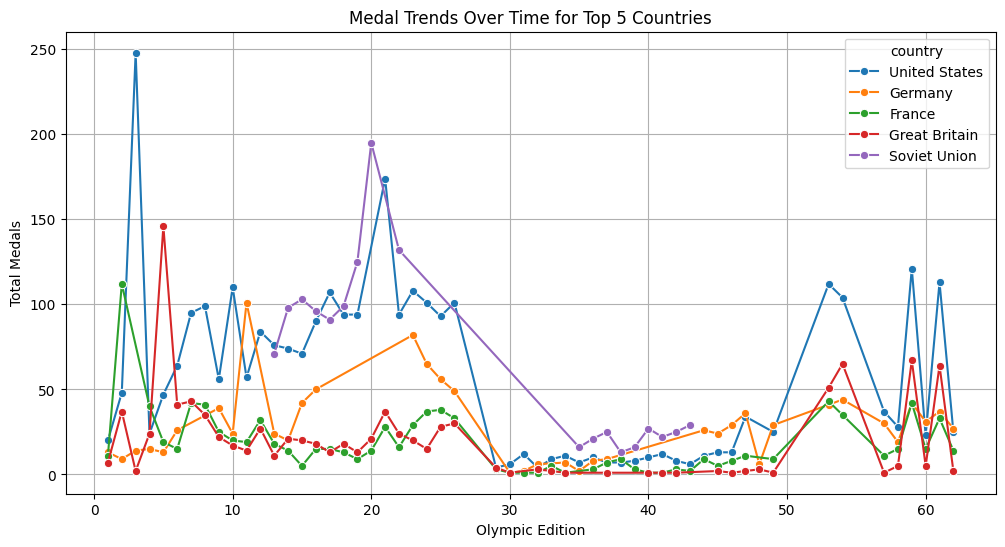

In [70]:
# Medal trends over editions
medal_trend = df_Olympic_Games_Medal_Tally[df_Olympic_Games_Medal_Tally['country'].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.lineplot(data=medal_trend, x='edition_id', y='total', hue='country', marker='o')
plt.title('Medal Trends Over Time for Top 5 Countries')
plt.xlabel('Olympic Edition')
plt.ylabel('Total Medals')
plt.grid(True)
plt.show()

**Participation trends across gender, age, sports**

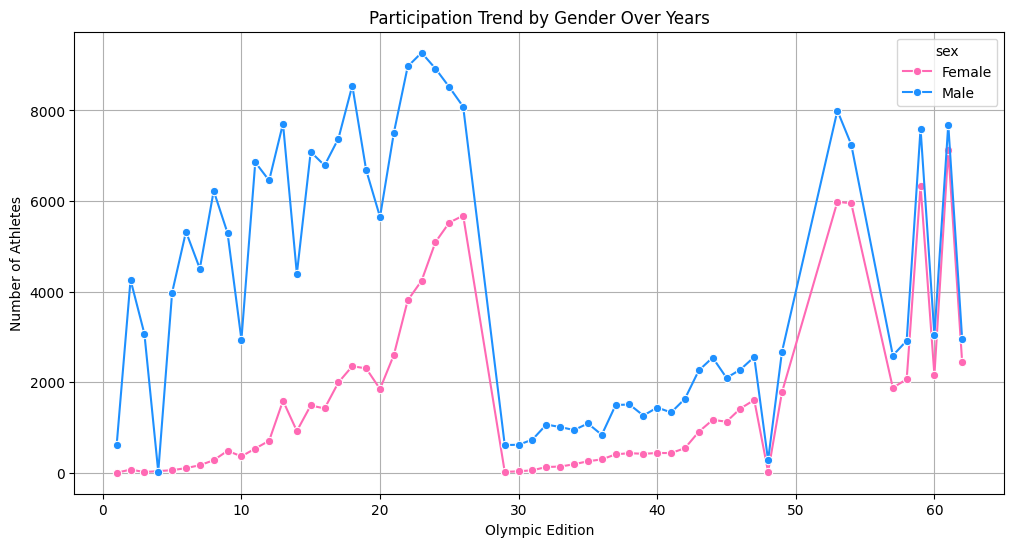

In [71]:
# Merge Athlete Bio with Event Results to get Gender + Year info together
athlete_participation = pd.merge(
    df_Olympic_Athlete_Event_Results,
    df_Olympic_Athlete_Bio[['athlete_id', 'sex']], 
    on='athlete_id',
    how='left'
)

# Gender Participation Trend
gender_colors = {
    'Female': '#FF69B4',  # Pink
    'Male': '#1E90FF'     # Blue
}
gender_trend = athlete_participation.groupby(['sex', 'edition_id']).size().reset_index(name='Counts')

plt.figure(figsize=(12,6))
sns.lineplot(data=gender_trend, x='edition_id', y='Counts', hue='sex',  palette=gender_colors, marker='o')
plt.title('Participation Trend by Gender Over Years')
plt.xlabel('Olympic Edition')
plt.ylabel('Number of Athletes')
plt.grid(True)
plt.show()

In [73]:
# Merge to bring Year and Birth_Date together
athlete_age = pd.merge(
    df_Olympic_Athlete_Event_Results[['athlete_id', 'year']],
    df_Olympic_Athlete_Bio[['athlete_id', 'born_year']],
    on='athlete_id',
    how='left'
)

In [74]:
# Convert Birth_Date to datetime if not already
athlete_age['born_year'] = pd.to_datetime(athlete_age['born_year'], errors='coerce')

# Calculate Age
athlete_age['Age'] = athlete_age['year'] - athlete_age['born_year'].dt.year

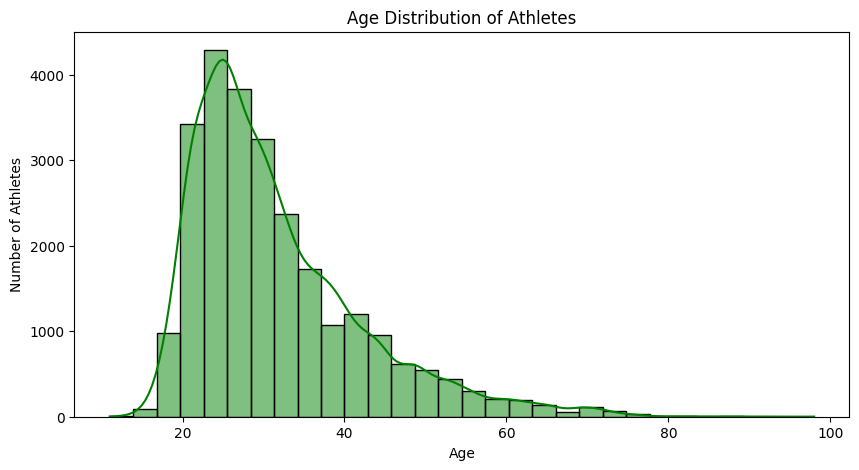

In [149]:
plt.figure(figsize=(10,5))
sns.histplot(athlete_age['Age'].dropna(), bins=30, kde=True, color='green')
plt.title('Age Distribution of Athletes')
plt.xlabel('Age')
plt.ylabel('Number of Athletes')
plt.show()

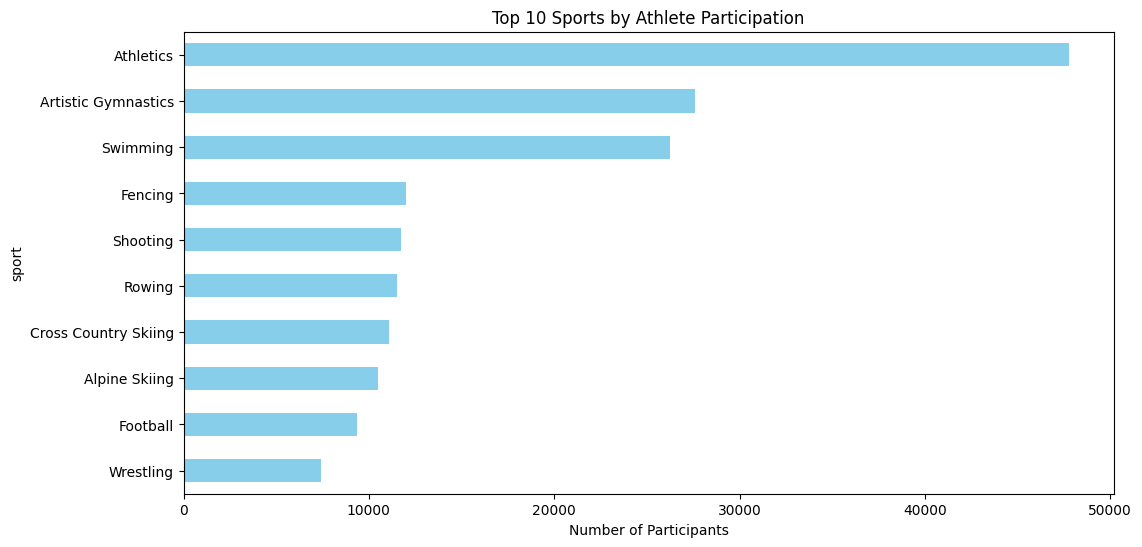

In [152]:
# Sport-wise Participation
sport_participation = df_Olympic_Athlete_Event_Results['sport'].value_counts().head(10)

plt.figure(figsize=(12,6))
sport_participation.plot(kind='barh', color='skyblue')
plt.title('Top 10 Sports by Athlete Participation')
plt.xlabel('Number of Participants')
plt.gca().invert_yaxis()
plt.show()

**Country-wise performance spikes/dips**

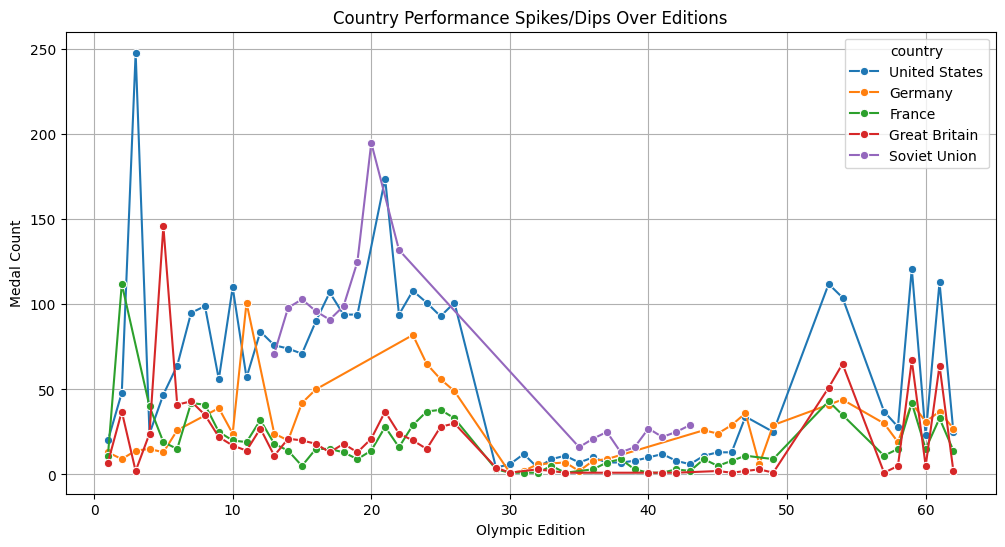

In [80]:
# Lineplot country performance
country_performance = df_Olympic_Games_Medal_Tally[df_Olympic_Games_Medal_Tally['country'].isin(top_countries)]

plt.figure(figsize=(12,6))
sns.lineplot(data=country_performance, x='edition_id', y='total', hue='country', marker='o')
plt.title('Country Performance Spikes/Dips Over Editions')
plt.xlabel('Olympic Edition')
plt.ylabel('Medal Count')
plt.grid(True)
plt.show()

**Dominance trends of countries in specific sports**

In [128]:
# Merge to get Sport
results_with_sport = pd.merge(
    df_Olympic_Results,
    df_Olympic_Athlete_Event_Results[['result_id', 'event', 'sport', 'country_noc']], 
    on='result_id',
    how='left'
)

In [165]:
print(results_with_sport.columns)

Index(['result_id', 'event_title', 'edition', 'edition_id', 'sport_x',
       'sport_url', 'result_date', 'result_location', 'result_participants',
       'result_format', 'result_detail', 'result_description', 'event',
       'sport_y', 'country_noc'],
      dtype='object')


In [166]:
top_countries = results_with_sport['country_noc'].value_counts().head(5).index.tolist()
print(top_countries)

['USA', 'FRA', 'GBR', 'ITA', 'CAN']


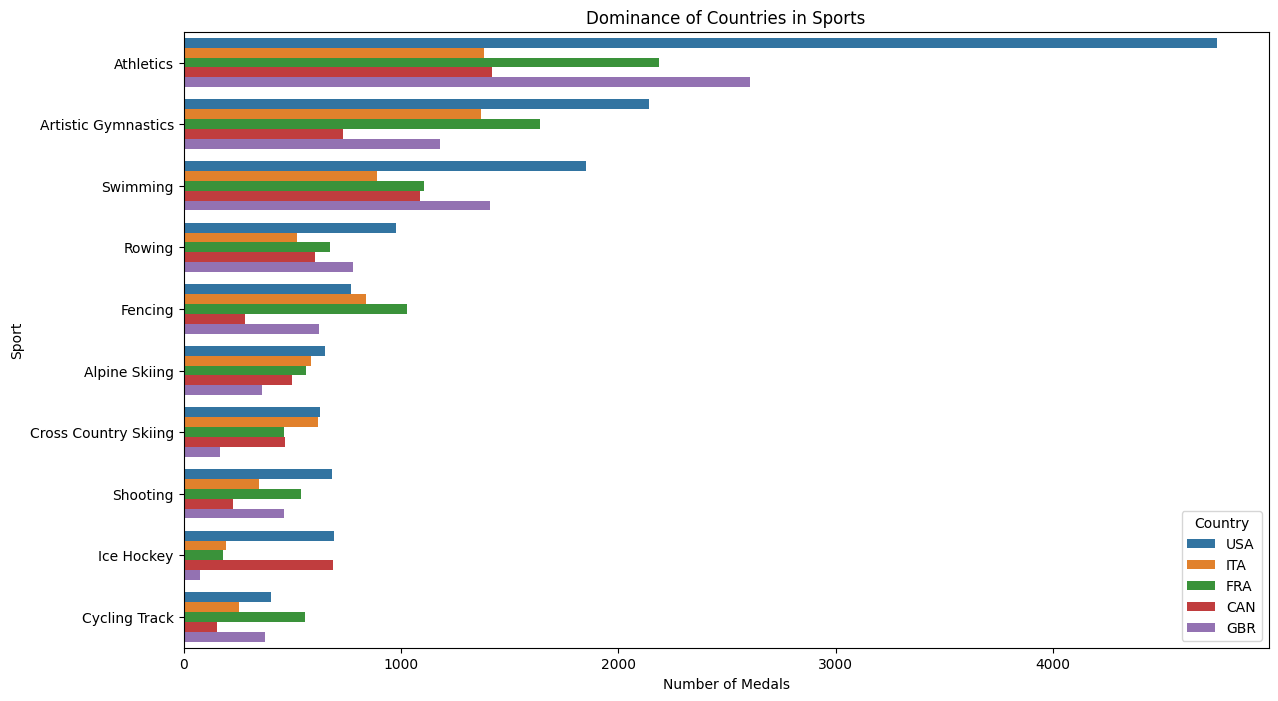

In [167]:
# Filter again
dominance = results_with_sport[results_with_sport['country_noc'].isin(top_countries)]

plt.figure(figsize=(14,8))
sns.countplot(
    data=dominance, 
    y='sport_y', 
    order=dominance['sport_y'].value_counts().head(10).index,
    hue='country_noc'
)
plt.title('Dominance of Countries in Sports')
plt.xlabel('Number of Medals')
plt.ylabel('Sport')
plt.legend(title='Country')
plt.show()

**Forecasting Task: Forecast the total medal count for top 5 countries in the next Olympic edition**

**Optional: Forecast medals by gender or sport category, Highlight insights from trend/seasonality/forecasts, (Optional): Classify countries into tiers based on past medal trends using clustering**

20:38:35 - cmdstanpy - INFO - Chain [1] start processing



 Forecasting medals for United States...



20:38:35 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


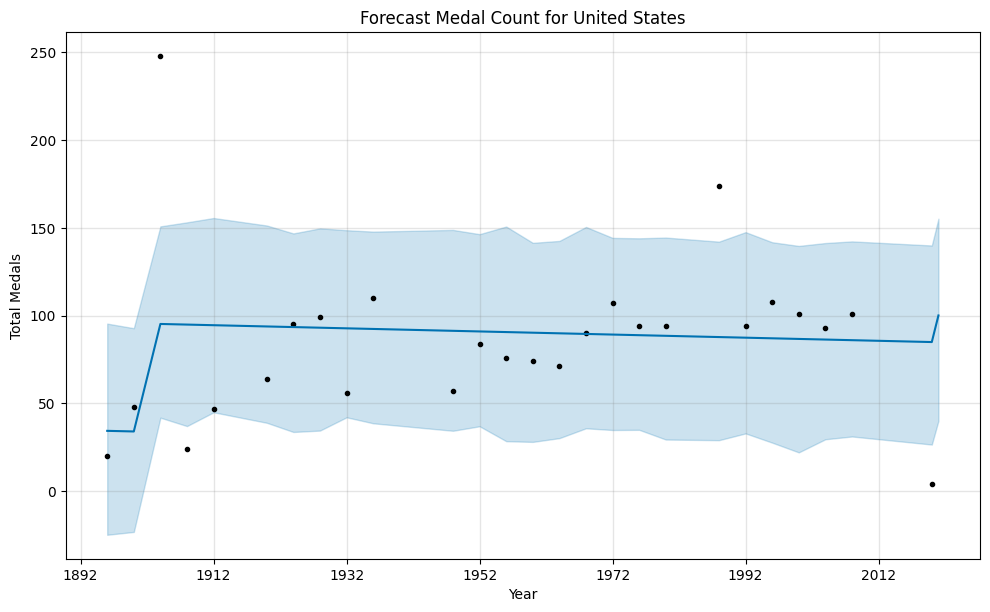

20:38:35 - cmdstanpy - INFO - Chain [1] start processing



 Forecasting medals for Soviet Union...



20:38:35 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


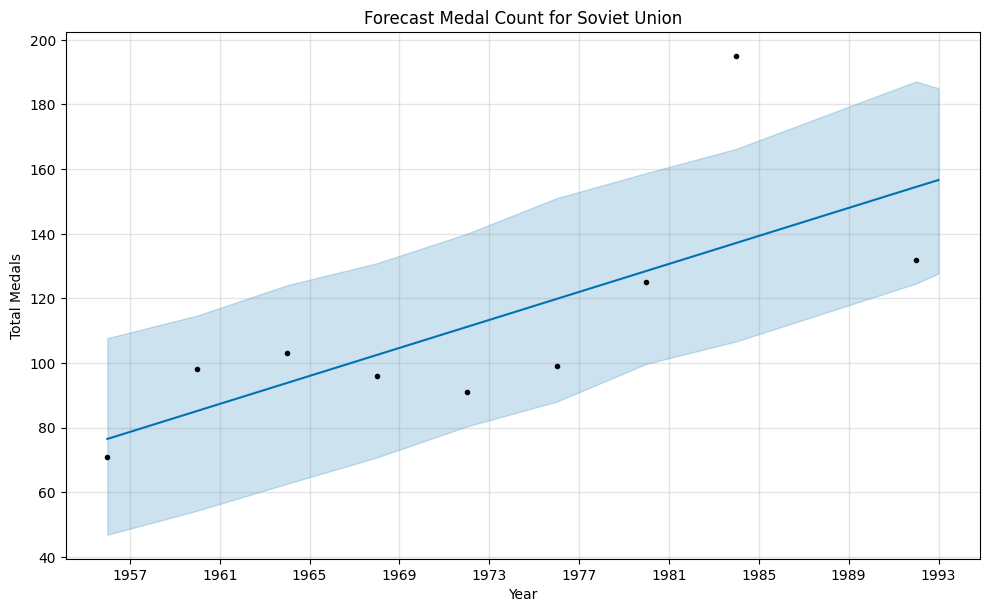

20:38:36 - cmdstanpy - INFO - Chain [1] start processing



 Forecasting medals for Great Britain...



20:38:36 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


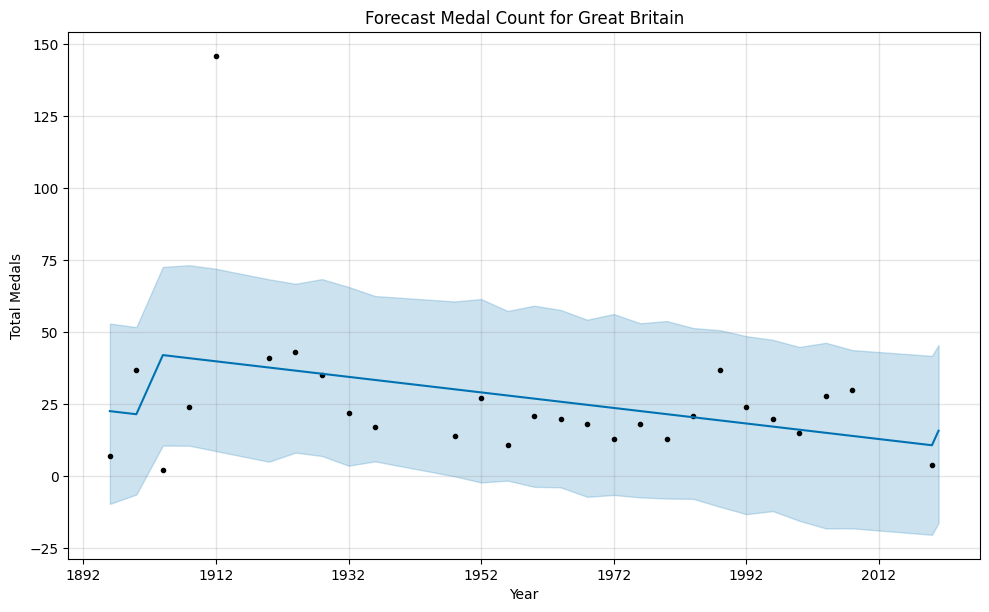

20:38:36 - cmdstanpy - INFO - Chain [1] start processing



 Forecasting medals for France...



20:38:36 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


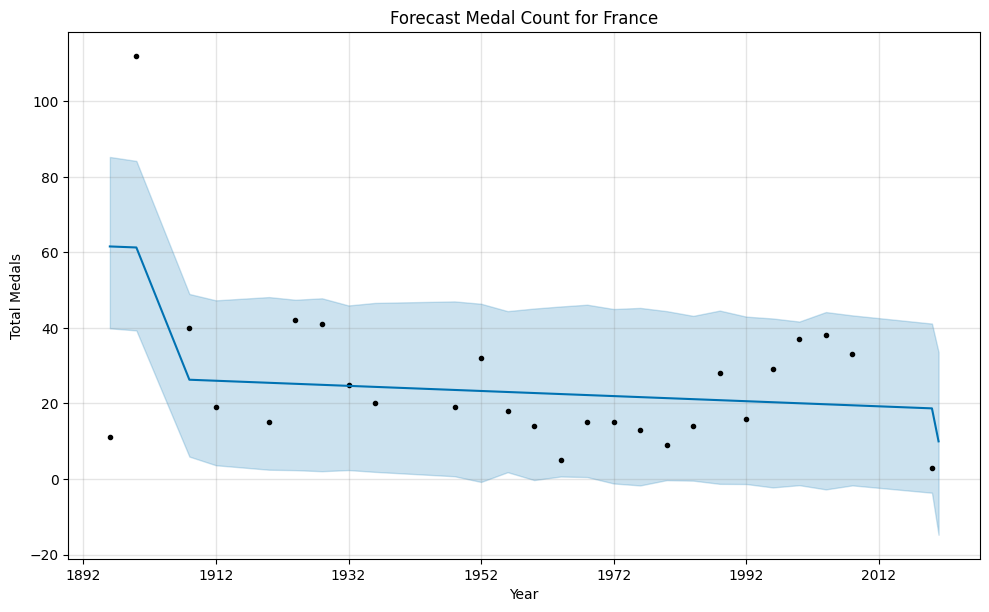

20:38:37 - cmdstanpy - INFO - Chain [1] start processing



 Forecasting medals for Germany...



20:38:37 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


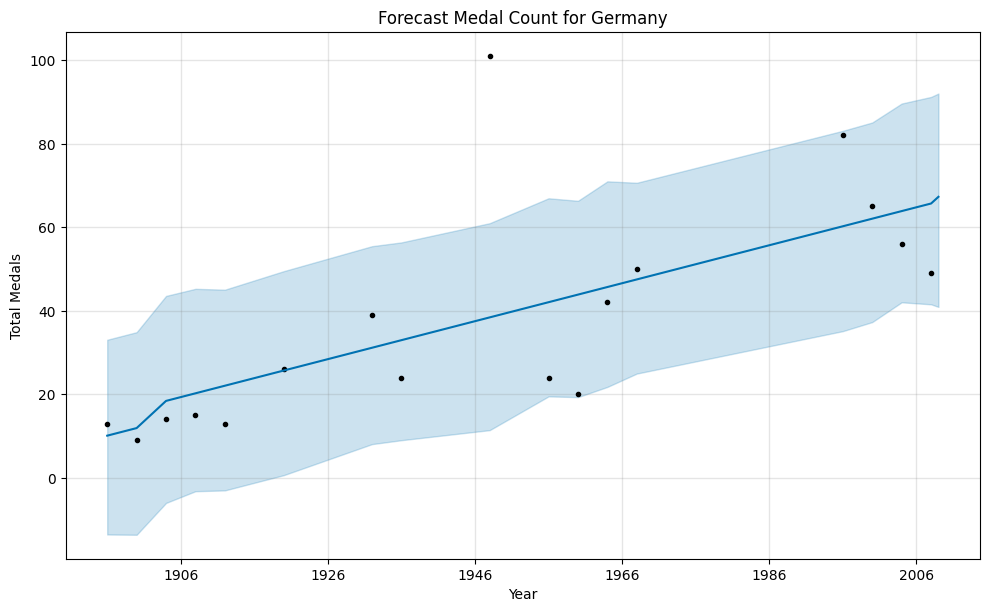


 Medal Forecast Summary for Top 5 Countries (Next Olympics):

                         ds        yhat  yhat_lower  yhat_upper
United States 26 2020-12-31  100.056483   40.004424  155.232914
Soviet Union  9  1992-12-31  156.603457  127.681180  185.004859
Great Britain 27 2020-12-31   15.814953  -16.297193   45.607519
France        26 2020-12-31    9.966558  -14.763631   33.605726
Germany       17 2008-12-31   67.277583   40.920554   92.007651


In [157]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

df = df_Olympic_Games_Medal_Tally.copy()

# Edition to Year Mapping
edition_mapping = {
    1: 1896, 2: 1900, 3: 1904, 4: 1908, 5: 1912, 6: 1920, 7: 1924, 8: 1928,
    9: 1932, 10: 1936, 11: 1948, 12: 1952, 13: 1956, 14: 1960, 15: 1964, 16: 1968,
    17: 1972, 18: 1976, 19: 1980, 20: 1984, 21: 1988, 22: 1992, 23: 1996,
    24: 2000, 25: 2004, 26: 2008, 27: 2012, 28: 2016, 29: 2020
}

df['year'] = df['edition_id'].map(edition_mapping)


df = df.dropna(subset=['year'])

# Get Top 5 Countries
top_countries = df.groupby('country')['total'].sum().sort_values(ascending=False).head(5).index.tolist()

# Forecasting Loop
forecast_results = {}

for country in top_countries:
    print(f"\n Forecasting medals for {country}...\n")
    
    # Country-specific data
    country_df = df[df['country'] == country][['year', 'total']].dropna()
    
    # Prepare for Prophet
    country_df = country_df.rename(columns={'year': 'ds', 'total': 'y'})
    country_df['ds'] = pd.to_datetime(country_df['ds'], format='%Y')
    
    # Double check - drop NaT if any
    country_df = country_df.dropna(subset=['ds', 'y'])
    
    if country_df.shape[0] < 2:
        print(f" Skipping {country}: Not enough data for Prophet")
        continue

    # Build & Fit Model
    model = Prophet()
    model.fit(country_df)
    
    # Future dataframe: 1 future Olympics (next 4 years)
    future = model.make_future_dataframe(periods=1, freq='4Y')
    forecast = model.predict(future)
    
    # Save forecast
    forecast_results[country] = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(1)
    
    # Plot
    fig = model.plot(forecast)
    plt.title(f"Forecast Medal Count for {country}")
    plt.xlabel('Year')
    plt.ylabel('Total Medals')
    plt.grid(True)
    plt.show()

# Show All Forecasts Together
print("\n Medal Forecast Summary for Top 5 Countries (Next Olympics):\n")
summary = pd.concat(forecast_results.values(), keys=forecast_results.keys())
print(summary)

In [162]:
# Medal tally data
df = df_Olympic_Games_Medal_Tally.copy()

# Pivot data: countries as rows, editions as columns
medal_pivot = df.pivot_table(index='country', columns='edition_id', values='total', fill_value=0)

medal_pivot.head()

edition_id,1,2,3,4,5,6,7,8,9,10,...,48,49,53,54,57,58,59,60,61,62
country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
Algeria,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0
Argentina,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,7.0,4.0,...,0.0,0.0,6.0,4.0,0.0,0.0,4.0,0.0,3.0,0.0
Armenia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,5.0,2.0,0.0,0.0,4.0,0.0,4.0,0.0
Australasia,0.0,0.0,0.0,0.0,5.0,7.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


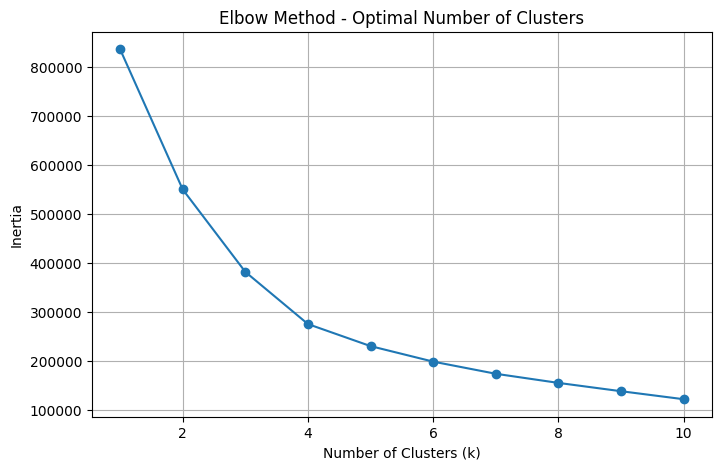

In [159]:
inertia = []

# Clustering from 1 to 10 groups
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(medal_pivot)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method - Optimal Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

In [160]:
# Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(medal_pivot)

# Cluster labels
medal_pivot['tier'] = clusters

# Mapping
tier_mapping = {0: 'Emerging', 1: 'Medium', 2: 'Top Performer'}
medal_pivot['tier'] = medal_pivot['tier'].map(tier_mapping)

medal_pivot.reset_index(inplace=True)

medal_pivot[['country', 'tier']].head(10)

edition_id,country,tier
0,Afghanistan,Emerging
1,Algeria,Emerging
2,Argentina,Emerging
3,Armenia,Emerging
4,Australasia,Emerging
5,Australia,Top Performer
6,Austria,Emerging
7,Azerbaijan,Emerging
8,Bahrain,Emerging
9,Barbados,Emerging


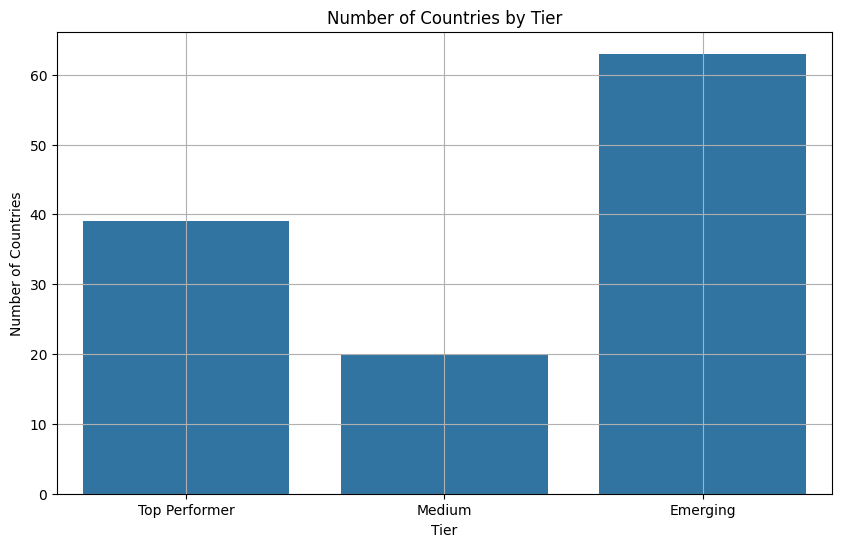

In [161]:
plt.figure(figsize=(10,6))
sns.countplot(data=medal_pivot, x='tier', order=['Top Performer', 'Medium', 'Emerging'])
plt.title('Number of Countries by Tier')
plt.xlabel('Tier')
plt.ylabel('Number of Countries')
plt.grid(True)
plt.show()